In [1]:
!git clone https://github.com/thunderbolt190/teleport-mcmc.git
%cd teleport-mcmc
!pip install -e ".[dev]" -q

import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
!pip install emcee
import emcee

from teleport.kernels.teleporting import teleporting_walkers_jax

Cloning into 'teleport-mcmc'...
remote: Enumerating objects: 772, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 772 (delta 29), reused 19 (delta 19), pack-reused 731 (from 2)
Receiving objects: 100% (772/772), 644.62 KiB | 18.96 MiB/s, done.
Resolving deltas: 100% (445/445), done.
/content/teleport-mcmc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 26.2 MB/s eta 0:00:00
  Building editable for teleport-mcmc (pyproject.toml) ..

In [2]:
key = jax.random.PRNGKey(42)
keys = jax.random.split(key, 3)

n_pts = 40
x = jax.random.normal(keys[0], shape = (n_pts, 3))

def fn(x):
  return jnp.prod(0.3 + 0.4 * x + 0.5 * jnp.sin(2.7 * x) + 1.1 / (1 + x ** 2), axis = -1)

sigma = jnp.where(jnp.abs(x) < 1.5, 0.125, 1.25)
delta = jnp.sum(sigma * jax.random.normal(keys[1], shape = (n_pts, 3)), axis = -1)

y = fn(x) + delta

print(x.shape)
print(y.shape)

print(x[:5])
print(y[:5])



(40, 3)
(40,)
[[-0.72030073 -0.26062233  1.68156851]
 [-0.19172768  1.46095216  1.82283169]
 [-0.26496813 -1.26575882 -1.33256835]
 [ 0.90686401  1.16454541 -0.35812046]
 [-0.33194193  1.15890695 -0.31412695]]
[-1.66117894 -0.73587206  0.01188974  1.08528237  1.04344244]


In [3]:
def log_prob_gp_multi(theta):
  alpha, c1, c2, c3, z21, z31, z32, sigma = theta
  valid = (alpha > 0) & (c1 > 0) & (c2 > 0) & (c3 > 0) & (sigma > 0)

  Z = jnp.array([
    [c1,  0,  0],
    [z21, c2, 0],
    [z31, z32, c3],
  ])
  A = Z @ Z.T

  diff = x[:, None, :] - x[None, :, :]
  quad_forms = jnp.einsum('ijk,kl,ijl->ij', diff, A, diff)
  K = alpha**2 * jnp.exp(-quad_forms)
  C = K + sigma**2 * jnp.eye(n_pts)

  L = jnp.linalg.cholesky(C)
  logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))
  v = jax.scipy.linalg.solve_triangular(L, y, lower=True)
  quad = jnp.sum(v**2)

  likelihood = -0.5 * logdet - 1/2 * quad - n_pts / 2 * jnp.log(2 * jnp.pi)

  log_prior = - jnp.log(1 + (alpha/3)**2) - jnp.log(1 + (sigma/3)**2)
  log_prior += -0.5 * (z21**2 + z31**2 + z32**2)
  log_prior += 2 * jnp.log(c1) - 0.5 * c1 ** 2
  log_prior += 1 * jnp.log(c2) - 0.5 * c2 ** 2
  log_prior += - 0.5 * c3 ** 2

  return jnp.where(valid, likelihood + log_prior, -jnp.inf)

In [4]:
theta_test = jnp.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5])
print(log_prob_gp_multi(theta_test))

theta_bad = jnp.array([1.0, -1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5])  # c1 < 0
print(log_prob_gp_multi(theta_bad))

-76.24434476060976
-inf


In [5]:
from teleport.kernels.teleporting import teleporting_walkers_jax

key = jax.random.PRNGKey(0)
n_walkers = 10

center = jnp.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5])
init = center + 0.05 * jax.random.normal(key, (n_walkers, 8))
init = init.at[:, 0].set(jnp.abs(init[:, 0]))   # alpha
init = init.at[:, 1:4].set(jnp.abs(init[:, 1:4]))  # c1,c2,c3
init = init.at[:, 7].set(jnp.abs(init[:, 7]))   # sigma

step_size = 0.05
n_steps = 200

final, chain, accepts, teleports = teleporting_walkers_jax(
    init, log_prob_gp_multi, step_size, n_steps, key
)

print(final.shape)
print(chain.shape)
print(float(jnp.mean(accepts)), float(jnp.mean(teleports)))
print(final[:2])

(10, 8)
(200, 10, 8)
0.7849999666213989 0.17000000178813934
[[ 1.26656993  0.92989313  1.36120311  1.20347516 -0.23247598  0.34602641
   0.43641861  0.58166701]
 [ 1.20177852  0.73899134  0.79515828  0.90659371  0.05244811  0.31905604
   0.17708204  0.6659334 ]]


In [6]:
def iat(n_walkers, key):
  keys = jax.random.split(key, 11)
  center = jnp.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5])
  init = center + 0.05 * jax.random.normal(keys[-1], (n_walkers, 8))
  iat = []

  for i in range(10):
    key = keys[i]
    n_steps = 100000
    step_size = 0.05
    burnin = 10000

    final_walkers, chain, accepts, teleports = teleporting_walkers_jax(init, log_prob_gp_multi, step_size, n_steps, key)

    avg = jnp.mean(chain, axis = 1)[burnin:, 1]

    iat.append(emcee.autocorr.integrated_time(avg, quiet=True)[0] / n_walkers)

  mean_iat = np.mean(iat)
  std_iat = np.std(iat)

  return mean_iat, std_iat

In [7]:
mean_iat = {}
std_iat = {}
Ns = [10, 20, 50, 100]

key = jax.random.PRNGKey(42)

mean, std = iat(10, key)
mean_iat[10] = mean
std_iat[10] = std

mean, std = iat(20, key)
mean_iat[20] = mean
std_iat[20] = std

mean, std = iat(50, key)
mean_iat[50] = mean
std_iat[50] = std

mean, std = iat(100, key)
mean_iat[100] = mean
std_iat[100] = std

print(mean_iat)
print(std_iat)

N/50 = 1800;
tau: [9758.14650398]
N/50 = 1800;
tau: [4511.92339389]
N/50 = 1800;
tau: [5645.94792728]
N/50 = 1800;
tau: [4335.55119352]
N/50 = 1800;
tau: [3770.8312403]
N/50 = 1800;
tau: [5487.92159846]
N/50 = 1800;
tau: [2834.95653225]
N/50 = 1800;
tau: [7202.91856768]
N/50 = 1800;
tau: [9633.75801721]
N/50 = 1800;
tau: [3803.90557755]
N/50 = 1800;
tau: [4264.073289]
N/50 = 1800;
tau: [2284.5880638]
N/50 = 1800;
tau: [5735.55362437]
N/50 = 1800;
tau: [5480.54722587]
N/50 = 1800;
tau: [1872.35935407]
N/50 = 1800;
tau: [5684.92171749]
N/50 = 1800;
tau: [10680.57290033]
N/50 = 1800;
tau: [8763.28927072]
N/50 = 1800;
tau: [10160.10060995]
N/50 = 1800;
tau: [6296.69114537]
N/50 = 1800;
tau: [12066.34970797]
N/50 = 1800;
tau: [13311.95393403]
N/50 = 1800;
tau: [5491.20573481]
N/50 = 1800;
tau: [12461.40735209]
N/50 = 1800;
tau: [11699.21848075]
N/50 = 1800;
tau: [8985.13149492]
N/50 = 1800;
tau: [12226.926784]
N/50 = 1800;
tau: [6595.88598779]
N/50 = 1800;
tau: [9208.31256423]
N/50 = 1800;


{10: np.float64(569.8586055213422), 20: np.float64(306.1134860048929), 50: np.float64(196.00876187419496), 100: np.float64(125.30901582953929)}
{10: np.float64(230.32202476360908), 20: np.float64(142.37509986209395), 50: np.float64(56.091875242384056), 100: np.float64(5.304671629497055)}


In [8]:
print("| N | Mean IAT / N | STD IAT |")
print("|---|---|---|")
for N in Ns:
  print(f"| {N} | {mean_iat[N]:.3f} | {std_iat[N]:.3f} |")

| N | Mean IAT / N | STD IAT |
|---|---|---|
| 10 | 569.859 | 230.322 |
| 20 | 306.113 | 142.375 |
| 50 | 196.009 | 56.092 |
| 100 | 125.309 | 5.305 |


| N | Mean IAT / N | STD IAT |
|---|---|---|
| 10 | 569.859 | 230.322 |
| 20 | 306.113 | 142.375 |
| 50 | 196.009 | 56.092 |
| 100 | 125.309 | 5.305 |

In [5]:
key = jax.random.PRNGKey(42)

n_walkers = 100
n_steps   = 100000
burnin    = 10000
step_size = 0.05

key1, key2 = jax.random.split(key)

center = jnp.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5])
init = center + 0.05 * jax.random.normal(key1, (n_walkers, 8))

final_walkers, chain, accepts, teleports = teleporting_walkers_jax(init, log_prob_gp_multi, step_size, n_steps, key2)

samples = chain[burnin:].reshape(-1, 8)

c1  = samples[:, 1]
z21 = samples[:, 4]
z32 = samples[:, 6]

Text(0, 0.5, '$c_1$')

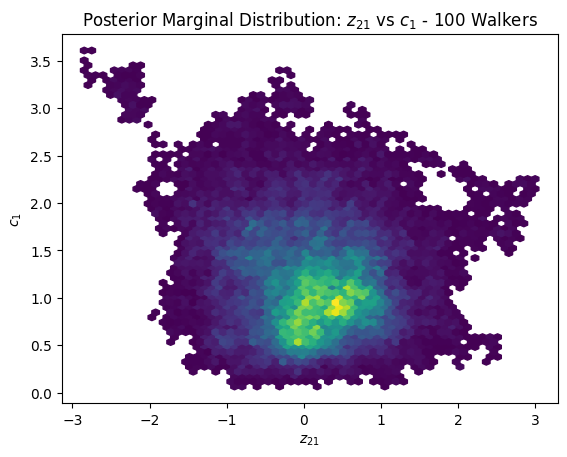

In [10]:
plt.hexbin(z21, c1, gridsize=60, cmap='viridis', mincnt=1)
plt.title(r"Posterior Marginal Distribution: $z_{21}$ vs $c_1$ - 100 Walkers")
plt.xlabel(r'$z_{21}$')
plt.ylabel(r'$c_1$')

Text(0, 0.5, '$z_{32}$')

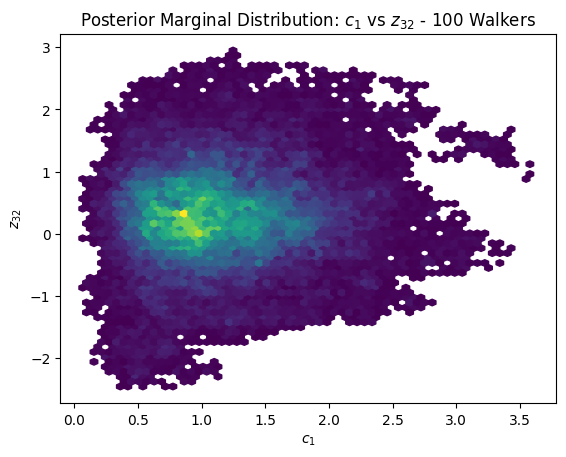

In [11]:
plt.hexbin(c1, z32, gridsize=60, cmap='viridis', mincnt=1)
plt.title(r"Posterior Marginal Distribution: $c_1$ vs $z_{32}$ - 100 Walkers")
plt.xlabel(r'$c_1$')
plt.ylabel(r'$z_{32}$')

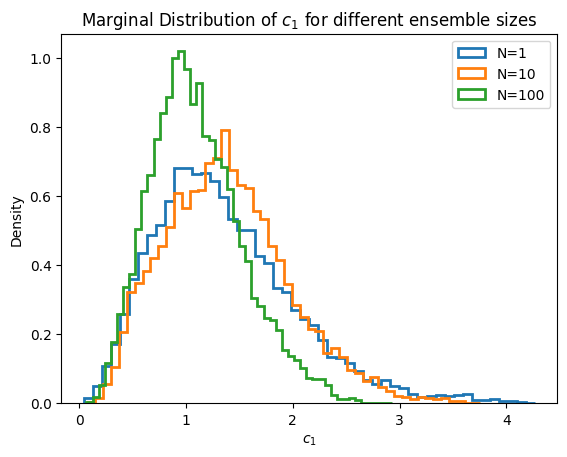

In [13]:
n_steps   = 50000
burnin    = 5000
step_size = 0.05
Ns_2 = [1, 10, 100]

key = jax.random.PRNGKey(42)
keys = jax.random.split(key, 6)
i = 0

for N in Ns_2:
  center = jnp.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.5])
  init = center + 0.05 * jax.random.normal(keys[i], (N, 8))
  final_walkers, chain, accepts, teleports = teleporting_walkers_jax(init, log_prob_gp_multi, step_size, n_steps, keys[i+1])
  i += 2
  c1_samples = chain[burnin:, :, 1].ravel()
  plt.hist(c1_samples, bins=50, density=True, histtype='step', linewidth=2, label=f'N={N}')
plt.xlabel(r'$c_1$')
plt.ylabel("Density")
plt.title(r"Marginal Distribution of $c_1$ for different ensemble sizes")
plt.legend()